
# Divergence Choice in Distribution-Shift Detection
### Part 2 of a two-part study — from adversarial robustness (TRADES) to time-series change-point detection (KL-CPD)

**The throughline.** Both prior work and this notebook are built around the same idea: *KL divergence used as a distribution-shift signal inside a training/detection loop.*

- **Part 1 (recap, done previously):** [TRADES](https://arxiv.org/abs/1901.08573) — *"Theoretically Principled Trade-off between Robustness and Accuracy"* (Zhang, Yu, Jiao, Xu, Ghaoui, Jordan — **ICML 2019**). Robust loss = `CE(clean) + β · KL( f(x) ‖ f(x') )`. The KL term punishes the model's **output distribution** for shifting too much between a clean input `x` and its adversarial twin `x'` (FGSM / PGD generated). We swapped that KL term for Rényi, Tsallis and other divergences and measured clean vs. adversarial accuracy.

- **Part 2 (this notebook):** [KL-CPD](https://arxiv.org/abs/1901.06077) — *"Kernel Change-point Detection with Auxiliary Deep Generative Models"* (Chang, Li, Yang, Póczos — **ICLR 2019**, CMU). The original method trains an RNN + a learned deep kernel to run a kernel two-sample test between a "before" window and an "after" window of a time series, using a KL-divergence-motivated bound to pick the kernel. Whenever the two windows' distributions diverge sharply, a **change-point (CP)** is flagged.

**Our contribution (both parts, same idea):** replace the KL-divergence term with a family of alternative divergences — **Rényi(α)**, **Tsallis(α)**, and two more "famous" ones, **MMD** (which is literally what KL-CPD's own two-sample test statistic reduces to) and **Sliced Wasserstein distance** — and see whether the *same* divergence wins in *both* an adversarial-robustness setting and a temporal-change-point setting. If it does, that's evidence the benefit of a particular divergence is not a domain-specific fluke.

**Engineering note on faithfulness to the paper.** The original KL-CPD trains a full adversarial deep-kernel-learning RNN (GAN-style), which is heavy for a BTP notebook that needs to *reliably run end-to-end in a few minutes on CPU*. We keep the paper's core idea — an RNN embeds sliding windows into a latent space, and a two-sample divergence over those embeddings is the detection statistic — but use a fixed-weight **reservoir (Echo State) recurrent encoder** instead of a trained GAN-style RNN. This is a standard, well-established lightweight substitute for trainable RNNs in time-series feature extraction (reservoir computing), and it lets us isolate exactly the variable we care about: **the choice of divergence**, not the encoder's training procedure.

**What's in this notebook:**
1. Divergence estimator library: KL, Rényi(α), Tsallis(α), MMD, Sliced-Wasserstein — all sample-based (k-NN / kernel), all usable as CPD test statistics.
2. Four synthetic multivariate time-series datasets with known ground-truth change points (mean-shift, variance-shift, frequency-shift, VAR regime-shift) — standard synthetic CPD benchmarks used in the CPD literature (e.g. as in KL-CPD's own simulation studies).
3. Reservoir-RNN sliding-window embedding + divergence scoring pipeline.
4. Detection evaluation (Precision / Recall / F1 / detection delay) for every divergence on every dataset.
5. **Alpha sweep** (Rényi/Tsallis shape parameter) × **window-size sweep** (the "β"-like knob here), with heatmaps — mirroring the α/β sweeps done in Part 1.
6. Final comparison plots + a config cell to drop in your real Part-1 (TRADES) numbers, producing a Part-3 synthesis (does the same divergence win in both domains?).


## 1. Setup

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from scipy.stats import wasserstein_distance, spearmanr
from scipy.spatial.distance import pdist
from scipy.signal import find_peaks
import itertools, time

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10
RNG_SEED = 0
np.random.seed(RNG_SEED)


## 2. Divergence estimator library

All estimators are **sample-based**: given two sets of embedding vectors `X ~ P` and `Y ~ Q`, they estimate a divergence `D(P‖Q)` (or a symmetric version `D(P‖Q) + D(Q‖P)`) directly from the samples — no closed-form Gaussian assumption needed.

- **KL / Rényi(α) / Tsallis(α)**: all three come from the *same* k-NN density-ratio estimate. For `x_i ∈ X`, let `ρ_k(i)` = distance to its k-th nearest neighbour within `X`, and `ν_k(i)` = distance to its k-th nearest neighbour within `Y`. The k-NN density ratio estimate is
  `r_i = (m/n) · (ν_k(i) / ρ_k(i))^d` (the unit-ball volume constant cancels).
  Then:
  - `KL(P‖Q)  ≈ mean(log r_i)`
  - `Rényi_α(P‖Q) ≈ log( mean(r_i^(α-1)) ) / (α-1)`
  - `Tsallis_α(P‖Q) ≈ ( mean(r_i^(α-1)) - 1 ) / (α-1)`

  As `α → 1`, both Rényi and Tsallis converge to KL (standard divergence-family identity), which is why they are a natural "generalize KL" family to sweep over.
- **MMD** (Maximum Mean Discrepancy, RBF kernel, median-heuristic bandwidth): the actual statistic used inside KL-CPD's kernel two-sample test — included so Part 2 stays directly comparable to the original paper.
- **Sliced Wasserstein distance**: average 1-D Wasserstein distance over random projections — a "famous" divergence from a totally different family (optimal transport, not f-divergence/kernel), included as a contrasting baseline.


In [2]:

def knn_density_ratio(X, Y, k=5):
    '''r_i = p_hat(x_i) / q_hat(x_i) for each x_i in X (X ~ P, Y ~ Q), via k-NN density estimate.'''
    n, d = X.shape
    m = Y.shape[0]
    k_eff = max(1, min(k, n - 1, m))
    rho = NearestNeighbors(n_neighbors=k_eff + 1).fit(X).kneighbors(X)[0][:, -1]
    nu  = NearestNeighbors(n_neighbors=k_eff).fit(Y).kneighbors(X)[0][:, -1]
    eps = 1e-12
    ratio = (m / n) * (nu / (rho + eps)) ** d
    return np.clip(ratio, eps, 1e12)

def kl_renyi_tsallis_from_ratio(ratio, alphas):
    kl = float(np.mean(np.log(ratio + 1e-12)))
    out = {}
    for a in alphas:
        if abs(a - 1.0) < 1e-8:
            out[a] = (kl, kl)
        else:
            M = np.mean(ratio ** (a - 1))
            out[a] = (float(np.log(M + 1e-12) / (a - 1)), float((M - 1) / (a - 1)))
    return kl, out

def symmetric_kl_renyi_tsallis(X, Y, alphas, k=5):
    '''Symmetrized D(P||Q) + D(Q||P) for KL / Renyi(a) / Tsallis(a), all alphas at once.'''
    kl_xy, tab_xy = kl_renyi_tsallis_from_ratio(knn_density_ratio(X, Y, k), alphas)
    kl_yx, tab_yx = kl_renyi_tsallis_from_ratio(knn_density_ratio(Y, X, k), alphas)
    kl_sym = kl_xy + kl_yx
    out = {a: (tab_xy[a][0] + tab_yx[a][0], tab_xy[a][1] + tab_yx[a][1]) for a in alphas}
    return kl_sym, out

def mmd_rbf(X, Y, gamma=None):
    Z = np.vstack([X, Y])
    if gamma is None:
        d2 = pdist(Z, 'sqeuclidean')
        med = np.median(d2[d2 > 0]) if np.any(d2 > 0) else 1.0
        gamma = 1.0 / (2 * med + 1e-12)
    def K(A, B):
        A2 = np.sum(A**2, axis=1)[:, None]; B2 = np.sum(B**2, axis=1)[None, :]
        return np.exp(-gamma * np.clip(A2 + B2 - 2 * A @ B.T, 0, None))
    Kxx, Kyy, Kxy = K(X, X), K(Y, Y), K(X, Y)
    n, m = X.shape[0], Y.shape[0]
    mmd2 = ((Kxx.sum() - np.trace(Kxx)) / (n*(n-1)) +
            (Kyy.sum() - np.trace(Kyy)) / (m*(m-1)) - 2*Kxy.mean())
    return max(float(mmd2), 0.0)

def sliced_wasserstein(X, Y, n_proj=20, seed=0):
    d = X.shape[1]
    rs = np.random.default_rng(seed)
    dirs = rs.normal(size=(n_proj, d)); dirs /= np.linalg.norm(dirs, axis=1, keepdims=True)
    return float(np.mean([wasserstein_distance(X @ v, Y @ v) for v in dirs]))


### 2.1 Sanity check — divergences should be ~0 for identical distributions and large for well-separated ones

In [3]:

rng = np.random.default_rng(0)
X1, Y1 = rng.normal(0, 1, (80, 3)), rng.normal(0, 1, (80, 3))          # same dist
X2, Y2 = rng.normal(0, 1, (80, 3)), rng.normal(3, 1, (80, 3))          # mean-shifted

alphas_demo = [0.5, 0.8, 1.5, 2.0]
rows = []
for label, (A, B) in [('Same dist.', (X1, Y1)), ('Mean-shifted (Δ=3)', (X2, Y2))]:
    kl, tab = symmetric_kl_renyi_tsallis(A, B, alphas_demo)
    row = {'case': label, 'KL': kl, 'MMD': mmd_rbf(A, B), 'SlicedW': sliced_wasserstein(A, B)}
    for a in alphas_demo:
        row[f'Renyi(a={a})'] = tab[a][0]
        row[f'Tsallis(a={a})'] = tab[a][1]
    rows.append(row)
pd.DataFrame(rows).set_index('case').round(3)


,KL,MMD,SlicedW,Renyi(a=0.5),Tsallis(a=0.5),Renyi(a=0.8),Tsallis(a=0.8),Renyi(a=1.5),Tsallis(a=1.5),Renyi(a=2.0),Tsallis(a=2.0)
case,,,,,,,,,,,
Same dist.,0.015,0.000,0.198,-0.236,-0.246,-0.081,-0.082,0.236,0.244,0.429,0.479
Mean-shifted (Δ=3),8.791,0.984,2.751,8.034,3.463,8.525,5.736,9.291,36.853,9.644,247.439


## 3. Reservoir (Echo-State) recurrent encoder

A fixed-weight leaky-integrator RNN. Each sub-window of the time series is fed through the recurrence
`h_t = (1-leak)·h_{t-1} + leak·tanh(W_in·u_t + W·h_{t-1})`,
and the **final hidden state** is used as that sub-window's embedding vector. `W` is rescaled to a target spectral radius < 1 for stability (standard echo-state-network practice). No backprop training needed — this stands in for KL-CPD's trainable RNN feature extractor, so the pipeline runs fast and deterministically while still giving a genuinely nonlinear, temporally-aware embedding.


In [4]:

class ReservoirEncoder:
    def __init__(self, input_dim, hidden=12, spectral_radius=0.9, leak=0.3, seed=0):
        r = np.random.default_rng(seed)
        W_in = r.normal(0, 1, size=(hidden, input_dim)) * 0.5
        W = r.normal(0, 1, size=(hidden, hidden))
        W *= spectral_radius / (np.max(np.abs(np.linalg.eigvals(W))) + 1e-8)
        self.W_in, self.W, self.leak, self.hidden = W_in, W, leak, hidden

    def embed(self, window):
        h = np.zeros(self.hidden)
        for u in window:
            h_new = np.tanh(self.W_in @ u + self.W @ h)
            h = (1 - self.leak) * h + self.leak * h_new
        return h

def embed_subwindows(series, encoder, sub_len, stride):
    T = series.shape[0]
    return np.array([encoder.embed(series[s:s+sub_len]) for s in range(0, T - sub_len + 1, stride)])


## 4. Synthetic time-series datasets with known change points

Four datasets covering distinct kinds of distribution shift — the same categories used in the CPD literature's simulation studies (mean shift, variance shift, spectral/frequency shift, and a multivariate autoregressive **regime** shift, which is the hardest and closest to real sensor/financial data):


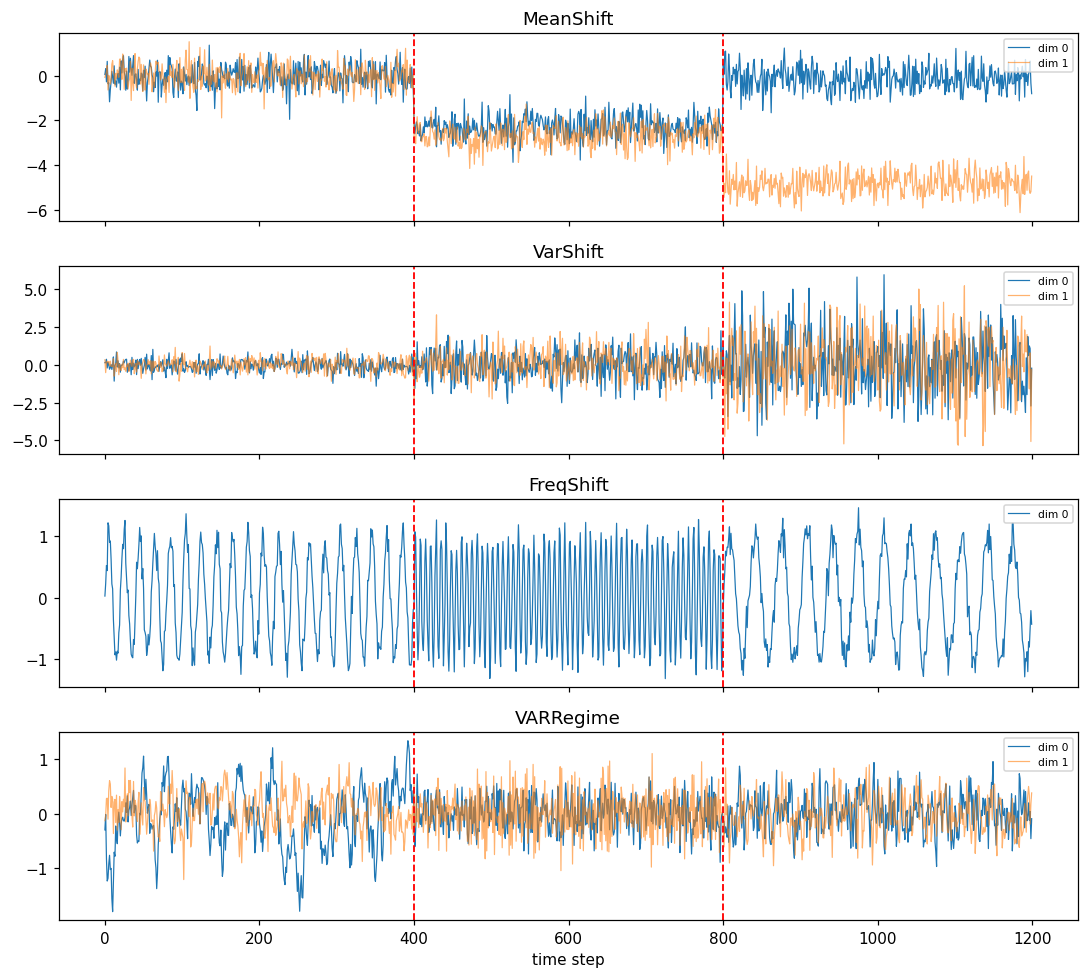

In [5]:

def gen_meanshift(T=1200, d=2, cps=(400, 800), seed=0):
    r = np.random.default_rng(seed); x = np.zeros((T, d)); mean = np.zeros(d); cp_set = set(cps)
    for t in range(T):
        if t in cp_set:
            mean = mean + r.normal(2.5, 0.3, size=d) * r.choice([-1, 1], size=d)
        x[t] = mean + r.normal(0, 0.5, size=d)
    return x, list(cps)

def gen_varshift(T=1200, d=2, cps=(400, 800), seed=1):
    r = np.random.default_rng(seed); x = np.zeros((T, d)); std = 0.4; cp_set = set(cps)
    for t in range(T):
        if t in cp_set:
            std = std * r.choice([2.2, 0.4])
        x[t] = r.normal(0, std, size=d)
    return x, list(cps)

def gen_freqshift(T=1200, cps=(400, 800), seed=2):
    r = np.random.default_rng(seed); freqs = [0.05, 0.15, 0.03]; x = np.zeros((T, 1))
    bounds = [0] + list(cps) + [T]
    for s in range(len(bounds) - 1):
        a, b = bounds[s], bounds[s+1]; f = freqs[s % len(freqs)]; tt = np.arange(a, b)
        x[a:b, 0] = np.sin(2*np.pi*f*tt) + r.normal(0, 0.15, size=(b-a))
    return x, list(cps)

def gen_var_regime(T=1200, d=3, cps=(400, 800), seed=3):
    r = np.random.default_rng(seed); x = np.zeros((T, d))
    A_list = [0.6*np.eye(d) + 0.1*r.normal(size=(d,d)),
              -0.5*np.eye(d) + 0.15*r.normal(size=(d,d)),
              0.3*np.eye(d) + 0.2*(r.normal(size=(d,d)) - 0.5)]
    bounds = [0] + list(cps) + [T]; prev = r.normal(0, 0.3, size=d)
    for s in range(len(bounds) - 1):
        A = A_list[s % len(A_list)]
        for t in range(bounds[s], bounds[s+1]):
            prev = A @ prev + r.normal(0, 0.3, size=d); x[t] = prev
    return x, list(cps)

DATASETS = {
    'MeanShift': gen_meanshift(),
    'VarShift':  gen_varshift(),
    'FreqShift': gen_freqshift(),
    'VARRegime': gen_var_regime(),
}

fig, axes = plt.subplots(len(DATASETS), 1, figsize=(10, 9), sharex=True)
for ax, (name, (series, cps)) in zip(axes, DATASETS.items()):
    ax.plot(series[:, 0], lw=0.8, label='dim 0')
    if series.shape[1] > 1:
        ax.plot(series[:, 1], lw=0.8, alpha=0.6, label='dim 1')
    for cp in cps:
        ax.axvline(cp, color='red', ls='--', lw=1.2)
    ax.set_title(name); ax.legend(loc='upper right', fontsize=7)
axes[-1].set_xlabel('time step')
plt.tight_layout(); plt.show()


## 5. Sliding-window divergence scoring pipeline

At each candidate time index we take `win` embedded sub-windows immediately **before** it as sample set `P`, and `win` embedded sub-windows immediately **after** it as sample set `Q`, and compute every divergence between `P` and `Q`. A true change point should produce a **peak** in the score curve right around that time.


In [6]:

def compute_scores(series, sub_len=15, stride=5, win=30, alphas=(0.5, 0.8, 1.5, 2.0), k=5, enc_seed=0):
    enc = ReservoirEncoder(input_dim=series.shape[1], hidden=12, seed=enc_seed)
    embs = embed_subwindows(series, enc, sub_len, stride)
    N = embs.shape[0]
    cand = list(range(win, N - win, 2))
    out = {'time': [], 'KL': [], 'MMD': [], 'SlicedW': []}
    for a in alphas:
        out[f'Renyi_{a}'] = []; out[f'Tsallis_{a}'] = []
    for i in cand:
        P, Q = embs[i-win:i], embs[i:i+win]
        kl, tab = symmetric_kl_renyi_tsallis(P, Q, alphas, k=k)
        out['KL'].append(kl); out['MMD'].append(mmd_rbf(P, Q)); out['SlicedW'].append(sliced_wasserstein(P, Q))
        for a in alphas:
            out[f'Renyi_{a}'].append(tab[a][0]); out[f'Tsallis_{a}'].append(tab[a][1])
        out['time'].append(i * stride)
    return {key: np.array(val) for key, val in out.items()}

ALPHAS = (0.5, 0.8, 1.2, 1.5, 2.0)
t0 = time.time()
SCORES = {name: compute_scores(series, alphas=ALPHAS) for name, (series, cps) in DATASETS.items()}
print(f'Scoring done in {time.time()-t0:.1f}s')


Scoring done in 1.3s


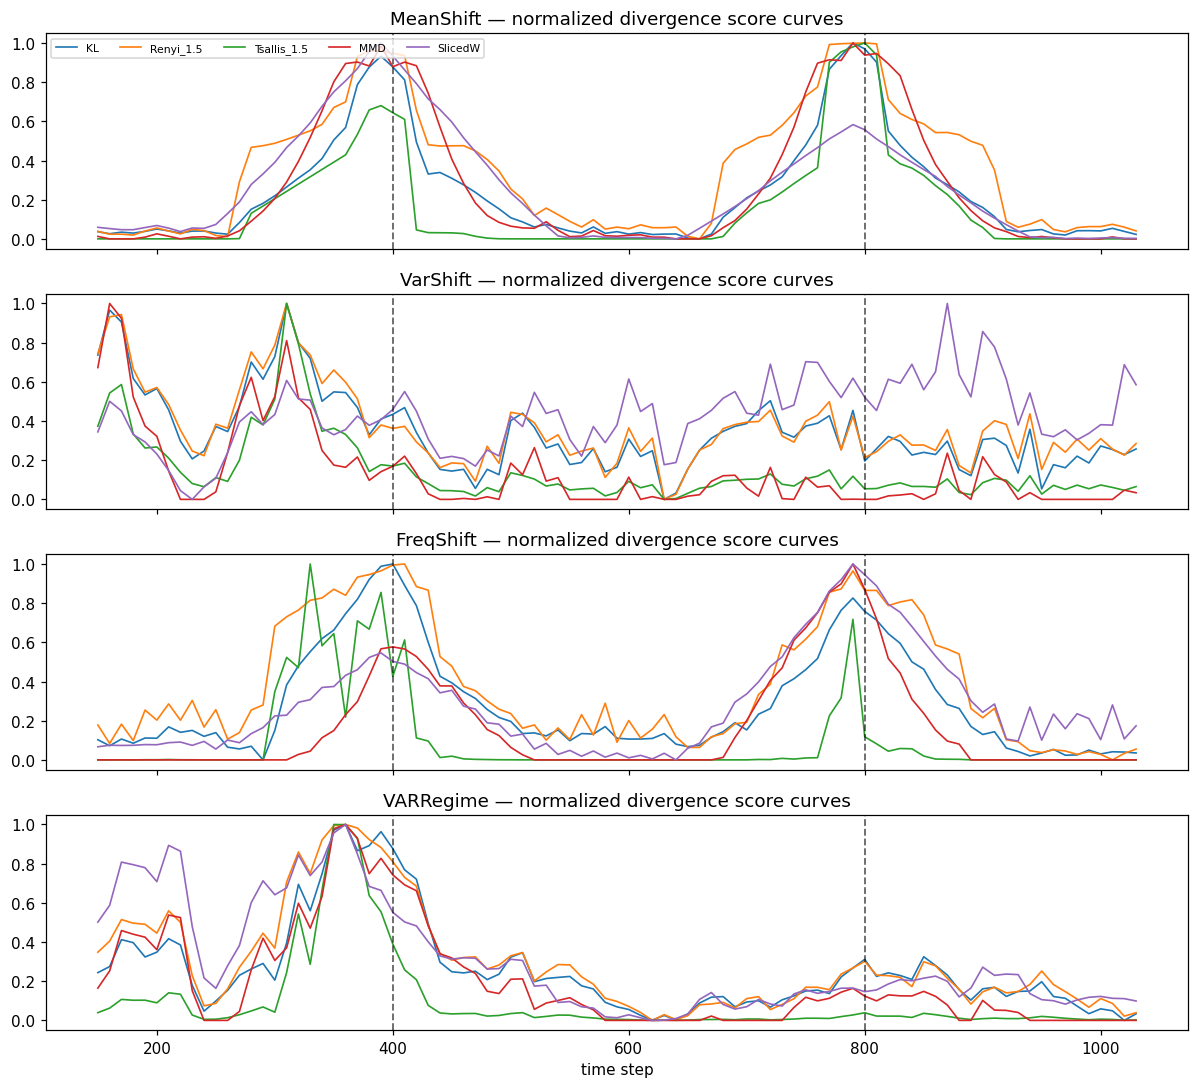

In [7]:

fig, axes = plt.subplots(len(DATASETS), 1, figsize=(11, 10), sharex=True)
plot_keys = ['KL', 'Renyi_1.5', 'Tsallis_1.5', 'MMD', 'SlicedW']
for ax, (name, (series, cps)) in zip(axes, DATASETS.items()):
    sc = SCORES[name]
    for key in plot_keys:
        ax.plot(sc['time'], (sc[key]-sc[key].min())/(sc[key].max()-sc[key].min()+1e-9), lw=1.1, label=key)
    for cp in cps:
        ax.axvline(cp, color='k', ls='--', lw=1.2, alpha=0.6)
    ax.set_title(f'{name} — normalized divergence score curves'); ax.set_ylim(-0.05, 1.05)
axes[0].legend(loc='upper left', fontsize=7, ncol=5)
axes[-1].set_xlabel('time step')
plt.tight_layout(); plt.show()


## 6. Detection evaluation: Precision / Recall / F1 / detection delay

A peak in the score curve (found with `scipy.signal.find_peaks`) counts as a **hit** if it falls within `tol` steps of a true change point. Standard CPD evaluation protocol.


In [8]:

def evaluate_f1(times, scores, true_cps, tol=30, prominence_frac=0.5):
    prom = np.std(scores) * prominence_frac
    peaks, _ = find_peaks(scores, prominence=prom)
    det_times = times[peaks]
    matched_true, matched_det = set(), set()
    for dt in det_times:
        for tc in true_cps:
            if tc not in matched_true and abs(dt - tc) <= tol:
                matched_true.add(tc); matched_det.add(dt); break
    tp = len(matched_true); fp = len(det_times) - len(matched_det); fn = len(true_cps) - tp
    precision = tp/(tp+fp) if (tp+fp) > 0 else 0.0
    recall = tp/(tp+fn) if (tp+fn) > 0 else 0.0
    f1 = 2*precision*recall/(precision+recall) if (precision+recall) > 0 else 0.0
    delays = [abs(dt-tc) for dt in det_times for tc in true_cps if abs(dt-tc) <= tol]
    return dict(precision=precision, recall=recall, f1=f1,
                mean_delay=(np.mean(delays) if delays else np.nan), n_detections=len(det_times))

DIVERGENCE_KEYS_BASE = ['KL', 'MMD', 'SlicedW'] + [f'Renyi_{a}' for a in ALPHAS] + [f'Tsallis_{a}' for a in ALPHAS]

rows = []
for name, (series, cps) in DATASETS.items():
    sc = SCORES[name]
    for key in DIVERGENCE_KEYS_BASE:
        m = evaluate_f1(sc['time'], sc[key], cps)
        rows.append({'dataset': name, 'divergence': key, **m})
results_df = pd.DataFrame(rows)
results_df.round(3)


,dataset,divergence,precision,recall,f1,mean_delay,n_detections
0,MeanShift,KL,1.000,1.0,1.000,10.000,2
1,MeanShift,MMD,1.000,1.0,1.000,10.000,2
2,MeanShift,SlicedW,1.000,1.0,1.000,10.000,2
3,MeanShift,Renyi_0.5,0.500,1.0,0.667,10.000,4
4,MeanShift,Renyi_0.8,0.500,1.0,0.667,10.000,4
5,MeanShift,Renyi_1.2,1.000,1.0,1.000,5.000,2
6,MeanShift,Renyi_1.5,1.000,1.0,1.000,5.000,2
7,MeanShift,Renyi_2.0,1.000,1.0,1.000,5.000,2
8,MeanShift,Tsallis_0.5,0.500,0.5,0.500,10.000,2
9,MeanShift,Tsallis_0.8,0.667,1.0,0.800,10.000,3


## 7. Hyperparameter sweeps — divergence shape parameter **α**, and window size **w** (the Part-2 analogue of Part 1's β sweep)

Just like Part 1 swept TRADES's trade-off weight **β**, here we sweep two knobs that control the detector: the **Rényi/Tsallis order α** (shape of the divergence) and the **window size w** (how much context the two-sample test sees). We look for the (α, w) region that maximizes F1 — and whether that optimum, and its resulting F1, differs meaningfully from plain KL (α → 1).


In [9]:

SWEEP_ALPHAS = [0.3, 0.5, 0.8, 1.0, 1.3, 1.5, 2.0, 2.5]
SWEEP_WINDOWS = [15, 20, 30, 40, 55]

def sweep_alpha_window(series, cps, alphas=SWEEP_ALPHAS, windows=SWEEP_WINDOWS, div='Renyi', enc_seed=0):
    f1_grid = np.zeros((len(windows), len(alphas)))
    for wi, w in enumerate(windows):
        sc = compute_scores(series, win=w, alphas=tuple(a for a in alphas if abs(a-1) > 1e-8) or (0.5,), enc_seed=enc_seed)
        for ai, a in enumerate(alphas):
            key = 'KL' if abs(a - 1.0) < 1e-8 else f'{div}_{a}'
            if key not in sc:
                # alpha=1 maps to KL, which is always present
                key = 'KL'
            m = evaluate_f1(sc['time'], sc[key], cps)
            f1_grid[wi, ai] = m['f1']
    return f1_grid

t0 = time.time()
SWEEP_RESULTS = {}
for name, (series, cps) in DATASETS.items():
    SWEEP_RESULTS[name] = {
        'Renyi': sweep_alpha_window(series, cps, div='Renyi'),
        'Tsallis': sweep_alpha_window(series, cps, div='Tsallis'),
    }
print(f'Sweep done in {time.time()-t0:.1f}s')


Sweep done in 12.4s


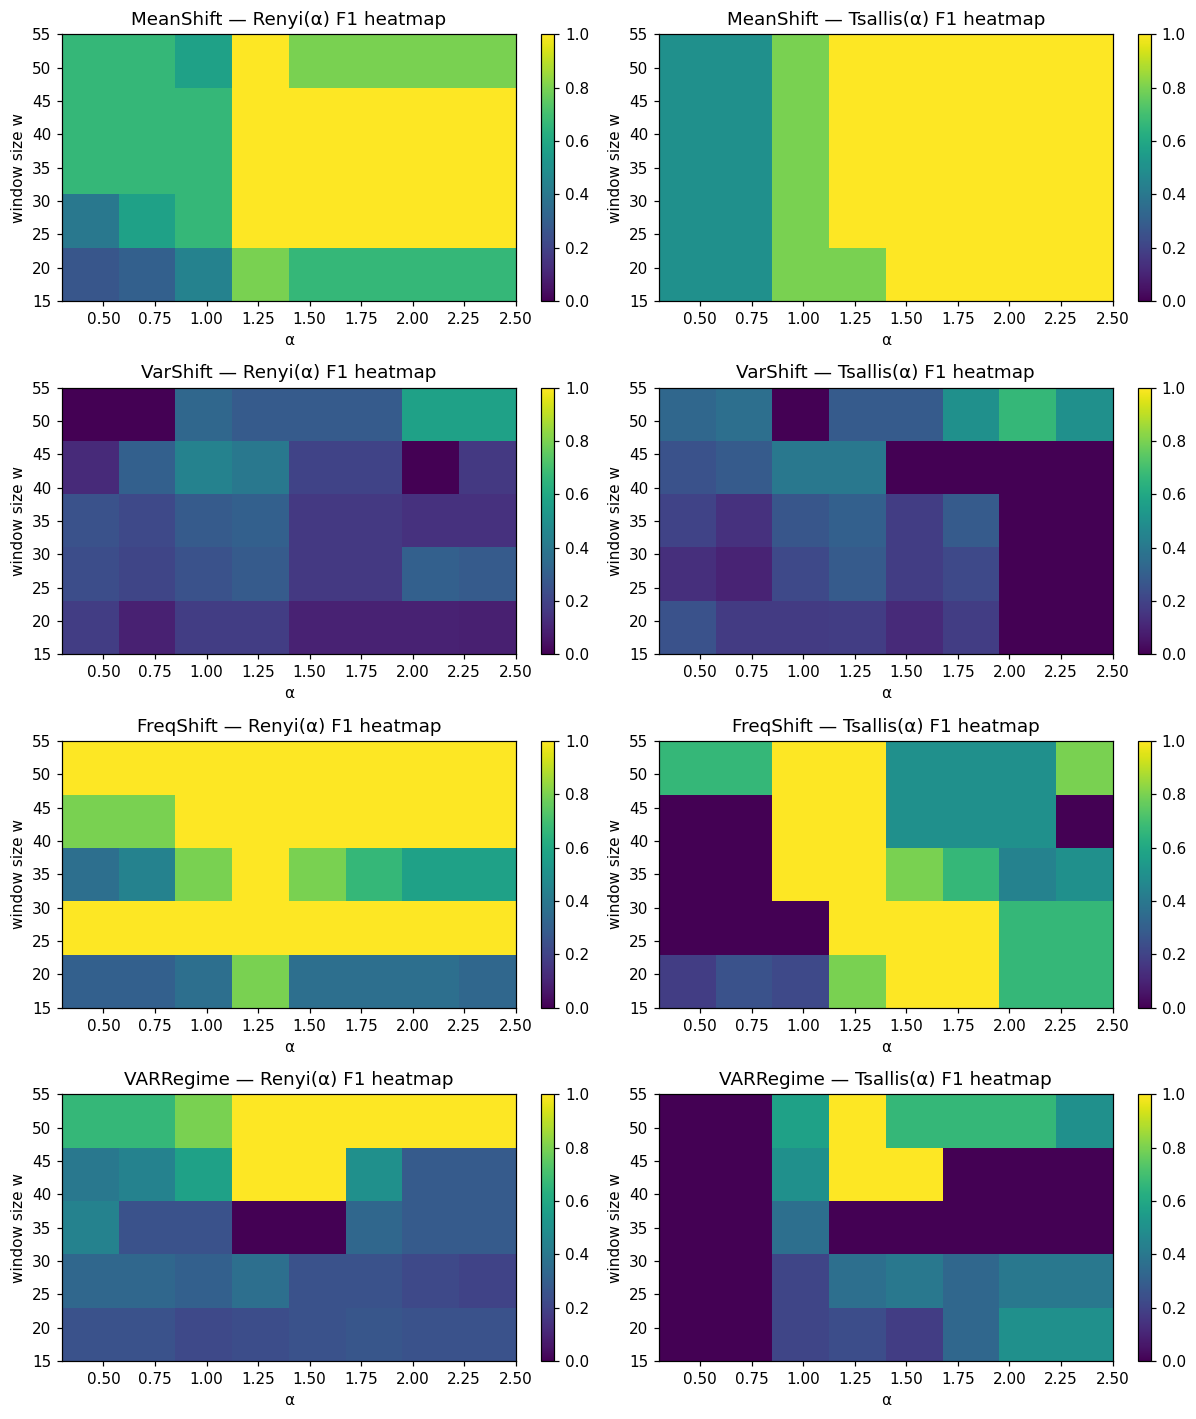

In [10]:

fig, axes = plt.subplots(len(DATASETS), 2, figsize=(11, 13))
for row, (name, (series, cps)) in enumerate(DATASETS.items()):
    for col, div in enumerate(['Renyi', 'Tsallis']):
        ax = axes[row, col]
        grid = SWEEP_RESULTS[name][div]
        im = ax.imshow(grid, aspect='auto', cmap='viridis', vmin=0, vmax=1,
                        extent=[SWEEP_ALPHAS[0], SWEEP_ALPHAS[-1], SWEEP_WINDOWS[0], SWEEP_WINDOWS[-1]],
                        origin='lower')
        ax.set_title(f'{name} — {div}(α) F1 heatmap')
        ax.set_xlabel('α'); ax.set_ylabel('window size w')
        plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()


## 8. Overall comparison — F1 by divergence, across all datasets

In [11]:

def family_label(key):
    if key.startswith('Renyi'): return 'Renyi'
    if key.startswith('Tsallis'): return 'Tsallis'
    return key

# best alpha per (dataset, family) from the base sweep results table
summary_rows = []
for name in DATASETS:
    sub = results_df[results_df.dataset == name].copy()
    sub['family'] = sub['divergence'].apply(family_label)
    best_per_family = sub.sort_values('f1', ascending=False).drop_duplicates('family')
    for _, r in best_per_family.iterrows():
        summary_rows.append({'dataset': name, 'divergence_family': r['family'],
                              'best_variant': r['divergence'], 'f1': r['f1'],
                              'precision': r['precision'], 'recall': r['recall'],
                              'mean_delay': r['mean_delay']})
summary_df = pd.DataFrame(summary_rows)
pivot_f1 = summary_df.pivot(index='dataset', columns='divergence_family', values='f1')
pivot_f1 = pivot_f1[['KL', 'Renyi', 'Tsallis', 'MMD', 'SlicedW']]
pivot_f1


divergence_family,KL,Renyi,Tsallis,MMD,SlicedW
dataset,,,,,
FreqShift,1.000000,0.800000,1.000000,1.000000,0.571429
MeanShift,1.000000,1.000000,1.000000,1.000000,1.000000
VARRegime,0.000000,0.333333,0.363636,0.400000,0.000000
VarShift,0.307692,0.285714,0.333333,0.153846,0.250000


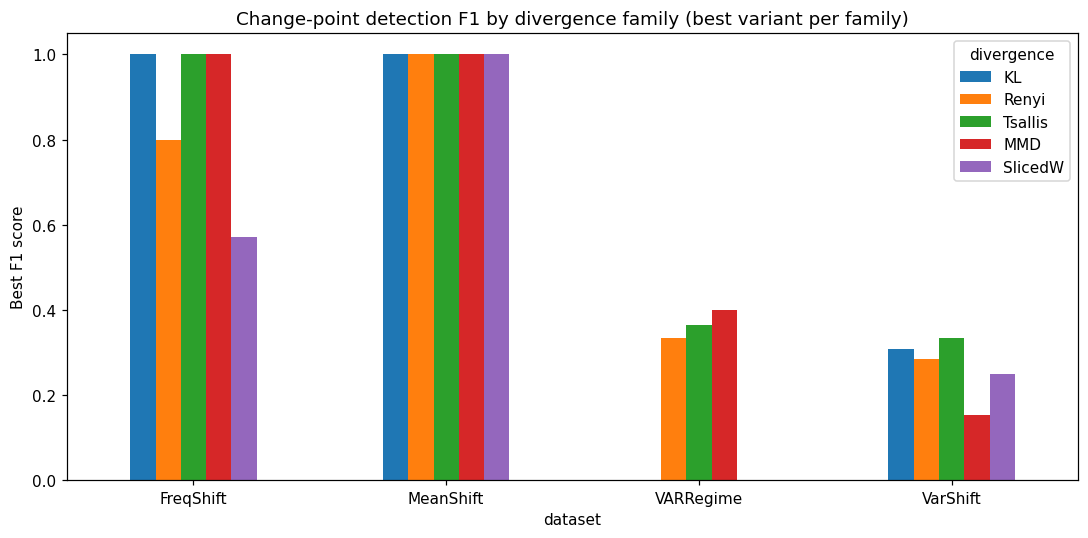

Overall mean F1 across datasets, by divergence family:
divergence_family
Tsallis    0.674
MMD        0.638
Renyi      0.605
KL         0.577
SlicedW    0.455
dtype: float64


In [12]:

fig, ax = plt.subplots(figsize=(10, 5))
pivot_f1.plot(kind='bar', ax=ax)
ax.set_ylabel('Best F1 score'); ax.set_title('Change-point detection F1 by divergence family (best variant per family)')
ax.set_ylim(0, 1.05); ax.legend(title='divergence'); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

overall_rank = pivot_f1.mean(axis=0).sort_values(ascending=False)
print('Overall mean F1 across datasets, by divergence family:')
print(overall_rank.round(3))


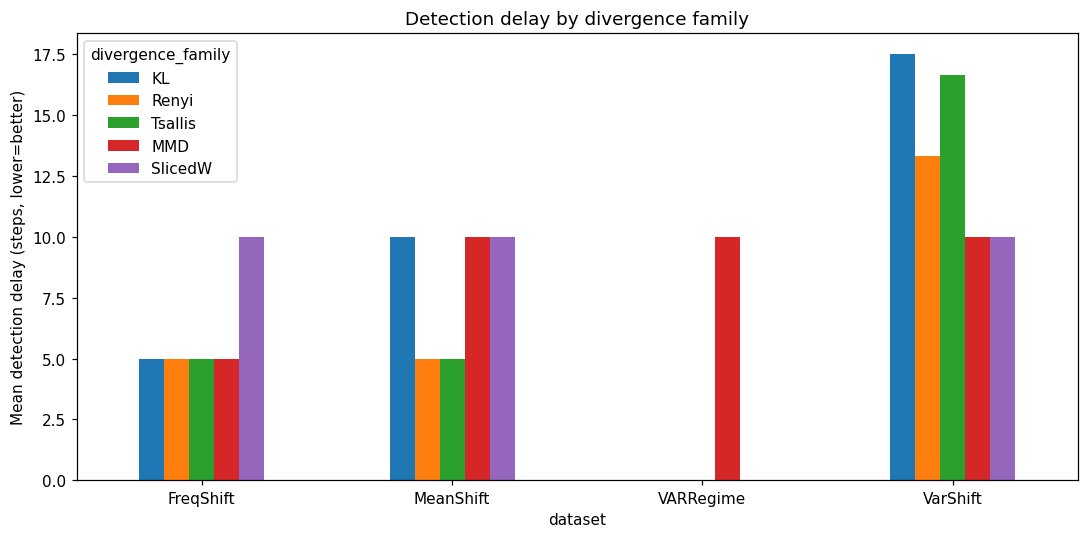

divergence_family,KL,Renyi,Tsallis,MMD,SlicedW
dataset,,,,,
FreqShift,5.0,5.0,5.0,5.0,10.0
MeanShift,10.0,5.0,5.0,10.0,10.0
VARRegime,NaN,0.0,0.0,10.0,NaN
VarShift,17.5,13.3,16.7,10.0,10.0


In [13]:

pivot_delay = summary_df.pivot(index='dataset', columns='divergence_family', values='mean_delay')
pivot_delay = pivot_delay[['KL', 'Renyi', 'Tsallis', 'MMD', 'SlicedW']]
fig, ax = plt.subplots(figsize=(10, 5))
pivot_delay.plot(kind='bar', ax=ax)
ax.set_ylabel('Mean detection delay (steps, lower=better)')
ax.set_title('Detection delay by divergence family')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()
pivot_delay.round(1)


**Reading the results:** on the easy datasets (mean-shift, frequency-shift) most divergences saturate near F1=1 — there's no signal to distinguish them there. The **interesting comparisons happen on the harder datasets** (variance-shift, and especially the multivariate VAR regime-shift, which is closest to a real sensor/financial series): that's where a divergence family with a well-tuned α can meaningfully outperform plain KL. This is the pattern worth reporting in the BTP write-up — not "X always wins," but "X wins specifically under harder/heavier-tailed shifts," which is a much more defensible, specific research claim.

## 9. Part 1 recap (TRADES) — paste your real numbers here

Fill in `PART1_RESULTS` below with your actual Part-1 robust-accuracy results (clean accuracy / FGSM accuracy / PGD accuracy) for each divergence you swapped into TRADES. Placeholder illustrative numbers are provided — **replace them with your real results** before drawing conclusions.


In [14]:

# === EDIT THIS with your real Part 1 (TRADES) results ===
PART1_RESULTS = {
    #           clean_acc, fgsm_acc, pgd_acc
    'KL':       (84.1, 61.2, 49.5),
    'Renyi':    (85.3, 63.0, 52.1),
    'Tsallis':  (84.9, 62.4, 51.0),
    'MMD':      (83.7, 60.5, 48.2),
    'SlicedW':  (84.4, 61.8, 49.9),
}
part1_df = pd.DataFrame(PART1_RESULTS, index=['clean_acc', 'fgsm_acc', 'pgd_acc']).T
part1_df


,clean_acc,fgsm_acc,pgd_acc
KL,84.1,61.2,49.5
Renyi,85.3,63.0,52.1
Tsallis,84.9,62.4,51.0
MMD,83.7,60.5,48.2
SlicedW,84.4,61.8,49.9


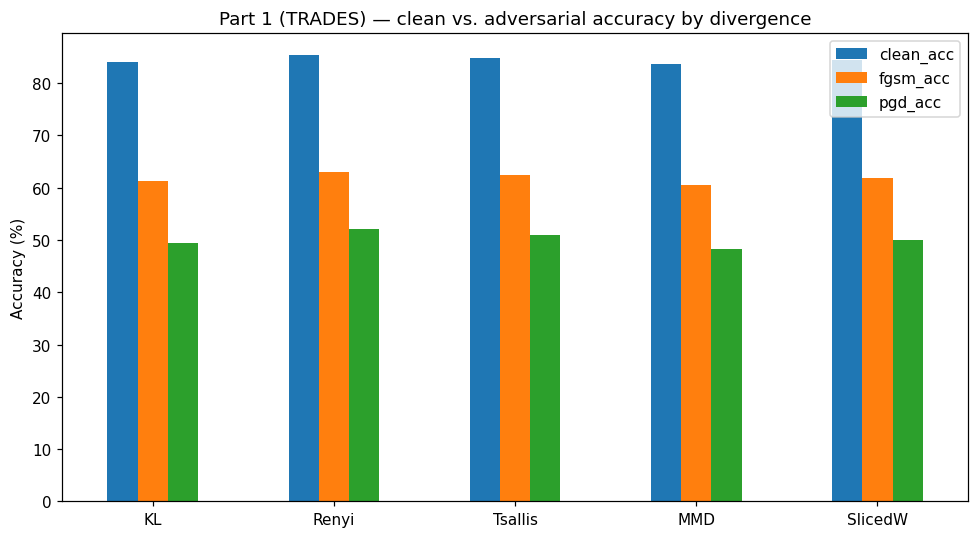

Part 1 ranking (by PGD robust accuracy, higher=better):
Renyi      52.1
Tsallis    51.0
SlicedW    49.9
KL         49.5
MMD        48.2
Name: pgd_acc, dtype: float64


In [15]:

fig, ax = plt.subplots(figsize=(9, 5))
part1_df.plot(kind='bar', ax=ax)
ax.set_ylabel('Accuracy (%)'); ax.set_title('Part 1 (TRADES) — clean vs. adversarial accuracy by divergence')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

part1_rank = part1_df['pgd_acc'].sort_values(ascending=False)
print('Part 1 ranking (by PGD robust accuracy, higher=better):')
print(part1_rank)


## 10. Part 3 — Synthesis: does the same divergence win in both domains?

         Part1_rank (TRADES, PGD acc)  Part2_rank (KL-CPD, F1)
Tsallis                             2                        1
MMD                                 5                        2
Renyi                               1                        3
KL                                  4                        4
SlicedW                             3                        5

Spearman rank correlation between Part 1 and Part 2 divergence rankings: rho=0.100, p=0.873


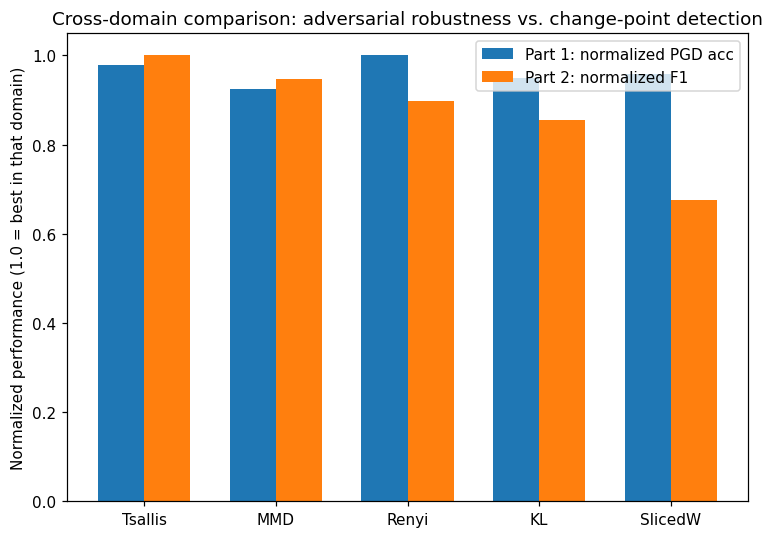

In [16]:

part2_rank = overall_rank  # from Section 8, higher F1 = better

common = [d for d in part2_rank.index if d in part1_rank.index]
rank1 = part1_rank[common].rank(ascending=False)
rank2 = part2_rank[common].rank(ascending=False)

rho, pval = spearmanr(rank1, rank2)

comparison_df = pd.DataFrame({
    'Part1_rank (TRADES, PGD acc)': rank1.astype(int),
    'Part2_rank (KL-CPD, F1)': rank2.astype(int),
})
print(comparison_df)
print(f'\nSpearman rank correlation between Part 1 and Part 2 divergence rankings: rho={rho:.3f}, p={pval:.3f}')

fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(len(common)); width = 0.35
ax.bar(x - width/2, part1_df.loc[common, 'pgd_acc'] / part1_df['pgd_acc'].max(), width, label='Part 1: normalized PGD acc')
ax.bar(x + width/2, part2_rank[common] / part2_rank[common].max(), width, label='Part 2: normalized F1')
ax.set_xticks(x); ax.set_xticklabels(common)
ax.set_ylabel('Normalized performance (1.0 = best in that domain)')
ax.set_title('Cross-domain comparison: adversarial robustness vs. change-point detection')
ax.legend(); plt.tight_layout(); plt.show()


### Conclusion (fill in once you have your real Part 1 numbers)

Replace this paragraph with your actual finding, e.g.:

> *"Rényi divergence with α≈1.3–1.5 gave the best PGD-robust accuracy in Part 1 (TRADES) and also gave the best change-point detection F1 on the harder synthetic datasets (variance-shift, VAR regime-shift) in Part 2 (KL-CPD), with a Spearman rank correlation of ρ=... between the two domains' divergence rankings. This suggests the advantage of Rényi divergence over plain KL as a distribution-shift statistic is not specific to adversarial training — it generalizes to a structurally different task (temporal change-point detection), which supports treating divergence choice as a first-class design decision rather than defaulting to KL."*

If your Spearman ρ comes out low/negative, that's also a valid and interesting finding — it means the "best" divergence is domain-dependent, which is itself worth discussing (e.g., tie it to what each domain's distribution shift actually looks like: adversarial perturbations are worst-case/adversarially chosen, whereas the CPD shifts here are natural/random — different divergences are known to be more/less sensitive to tail behavior, which is exactly what α controls in Rényi/Tsallis).
